# British Airways – Prédire la finalisation d'une réservation (Forage Task 2)

**Question** : à partir des informations saisies pendant la réservation, peut-on prédire si le client ira jusqu'au bout (`booking_complete = 1`) ? Et surtout : **qu'est-ce qui fait qu'il réserve ?**

**Démarche**
1. Exploration des données et des taux de conversion.
2. Préparation et création de variables, dont une variable originale : **le rôle du voyageur** (part-il de chez lui, rentre-t-il chez lui, ou réserve-t-il depuis un pays tiers ?).
3. Découpage **70 % train / 15 % validation / 15 % test** (stratifié), puis un premier banc d'essai en validation croisée.
4. **Réglage des hyperparamètres** de Random Forest, XGBoost et CatBoost avec Optuna, en optimisant la PR-AUC de validation. Le meilleur modèle est retenu.
5. **Évaluation finale, une seule fois, sur le test** : ROC-AUC, PR-AUC, F1 avec un seuil choisi sur la validation, et capture des réservations.
6. Interprétation : importance par permutation et SHAP.
7. Génération de la diapositive de synthèse.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
import optuna

SEED = 42
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# Palette & chart style (thin marks, recessive axes, text in ink colours, never series colour)
BLUE, GREY, INK, INK2, MUTED, SURFACE = "#2a78d6", "#b9b7b0", "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Chargement et exploration

In [2]:
df_raw = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
print(df_raw.shape)
print("Valeurs manquantes :", df_raw.isna().sum().sum(), "| doublons exacts :", df_raw.duplicated().sum())
print("Taux de réservation :", f"{df_raw.booking_complete.mean():.1%}")
df_raw.head()

(50000, 14)
Valeurs manquantes : 0 | doublons exacts : 719
Taux de réservation : 15.0%


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.520,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.520,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.520,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.520,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.520,0


In [3]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.000,1.591,1.020,1.000,1.000,1.000,2.000,9.000
purchase_lead,50000.000,84.940,90.451,0.000,21.000,51.000,115.000,867.000
length_of_stay,50000.000,23.045,33.888,0.000,5.000,17.000,28.000,778.000
flight_hour,50000.000,9.066,5.413,0.000,5.000,9.000,13.000,23.000
wants_extra_baggage,50000.000,0.669,0.471,0.000,0.000,1.000,1.000,1.000
wants_preferred_seat,50000.000,0.297,0.457,0.000,0.000,0.000,1.000,1.000
wants_in_flight_meals,50000.000,0.427,0.495,0.000,0.000,0.000,1.000,1.000
flight_duration,50000.000,7.278,1.497,4.670,5.620,7.570,8.830,9.500
booking_complete,50000.000,0.150,0.357,0.000,0.000,0.000,0.000,1.000


**Premières observations**
- Aucune valeur manquante, mais **719 doublons exacts**. On les supprime, sinon une même ligne pourrait se retrouver à la fois dans l'apprentissage et dans le test de la validation croisée.
- **La cible est déséquilibrée (~15 %)** : l'accuracy n'est pas pertinente. On utilisera ROC-AUC et surtout PR-AUC.
- `purchase_lead` et `length_of_stay` ont des queues très longues (jusqu'à 867 et 778 jours). Les arbres y sont insensibles, on les garde telles quelles.
- `route` (799 valeurs) et `booking_origin` (104 pays) sont des variables à très forte cardinalité.

In [4]:
df = df_raw.drop_duplicates().reset_index(drop=True)
df["flight_day"] = df["flight_day"].map({"Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5, "Sat": 6, "Sun": 7})
df["booking_origin"] = df["booking_origin"].replace({"Czech Republic": "Czechia", "(not set)": "Unknown"})
BASE_RATE = df.booking_complete.mean()
print(df.shape, f"| taux de réservation après dédoublonnage : {BASE_RATE:.1%}")

(49281, 14) | taux de réservation après dédoublonnage : 15.0%


In [5]:
def conversion(data, col, min_n=0):
    g = data.groupby(col)["booking_complete"].agg(n="size", rate="mean")
    return g[g.n >= min_n].sort_values("rate", ascending=False)

for col in ["sales_channel", "trip_type", "num_passengers", "flight_day"]:
    display(conversion(df, col))

,n,rate
sales_channel,,
Internet,43917,0.155
Mobile,5364,0.110


,n,rate
trip_type,,
RoundTrip,48779,0.151
OneWay,386,0.052
CircleTrip,116,0.043


,n,rate
num_passengers,,
9,64,0.203
5,544,0.195
6,281,0.189
3,2882,0.169
2,12669,0.160
4,1767,0.154
7,107,0.150
1,30879,0.143
8,88,0.136


,n,rate
flight_day,,
3,7562,0.163
4,7323,0.151
1,7988,0.149
6,5723,0.149
2,7558,0.148
5,6685,0.146
7,6442,0.141


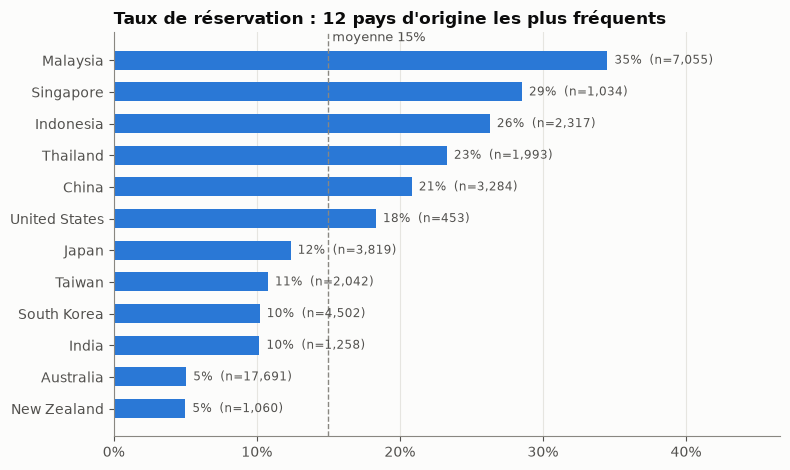

In [6]:
top_origins = conversion(df, "booking_origin").sort_values("n", ascending=False).head(12).sort_values("rate")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(top_origins.index, top_origins.rate, color=BLUE, height=0.6)
ax.axvline(BASE_RATE, color=MUTED, ls="--", lw=1)
ax.text(BASE_RATE, len(top_origins) - 0.4, f" moyenne {BASE_RATE:.0%}", color=INK2, fontsize=9)
for i, (rate, n) in enumerate(zip(top_origins.rate, top_origins.n)):
    ax.text(rate + 0.005, i, f"{rate:.0%}  (n={n:,})", va="center", fontsize=8.5, color=INK2)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_xlim(0, top_origins.rate.max() * 1.35); ax.grid(axis="y", visible=False)
ax.set_title("Taux de réservation : 12 pays d'origine les plus fréquents")
fig.tight_layout(); fig.savefig(FIG_DIR / "conversion_by_origin.png", dpi=200); plt.show()

Le pays d'origine est très discriminant : la **Malaisie convertit à ~35 %**, alors que l'**Australie**, premier marché en volume, **ne convertit qu'à ~5 %**. Les routes partant de ou arrivant en Malaisie (KUL, PEN…) semblent être le cœur du réseau. C'est ce qui inspire la variable « rôle du voyageur ».

## 2. Feature engineering

### 2.1 Le rôle du voyageur (variable originale)
Chaque route est une paire d'aéroports (ex. `KULICN`). En associant les 94 aéroports à leur pays, on compare le pays du client au pays de départ et au pays d'arrivée :

| Rôle | Exemple | Intuition |
|---|---|---|
| `home_departure` | un Malaisien réserve KUL→ICN | il part de chez lui : intention concrète |
| `return_home` | un Malaisien réserve ICN→KUL | il organise son retour |
| `third_country` | un Australien réserve KUL→ICN | plutôt une recherche exploratoire |

In [7]:
AIRPORT_COUNTRY = {
    "AKL": "New Zealand", "AOR": "Malaysia", "BBI": "India", "BDO": "Indonesia", "BKI": "Malaysia",
    "BLR": "India", "BOM": "India", "BTJ": "Indonesia", "BTU": "Malaysia", "BWN": "Brunei",
    "CAN": "China", "CCU": "India", "CEB": "Philippines", "CGK": "Indonesia", "CKG": "China",
    "CMB": "Sri Lanka", "CNX": "Thailand", "COK": "India", "CRK": "Philippines", "CSX": "China",
    "CTS": "Japan", "CTU": "China", "CXR": "Vietnam", "DAC": "Bangladesh", "DAD": "Vietnam",
    "DEL": "India", "DMK": "Thailand", "DPS": "Indonesia", "GOI": "India", "HAN": "Vietnam",
    "HDY": "Thailand", "HGH": "China", "HKG": "Hong Kong", "HKT": "Thailand", "HND": "Japan",
    "HYD": "India", "ICN": "South Korea", "IKA": "Iran", "JED": "Saudi Arabia", "JHB": "Malaysia",
    "JOG": "Indonesia", "KBR": "Malaysia", "KBV": "Thailand", "KCH": "Malaysia", "KHH": "Taiwan",
    "KIX": "Japan", "KLO": "Philippines", "KNO": "Indonesia", "KOS": "Cambodia", "KTM": "Nepal",
    "KUL": "Malaysia", "KWL": "China", "LBU": "Malaysia", "LGK": "Malaysia", "LOP": "Indonesia",
    "LPQ": "Laos", "MAA": "India", "MEL": "Australia", "MFM": "Macau", "MLE": "Maldives",
    "MNL": "Philippines", "MRU": "Mauritius", "MYY": "Malaysia", "NRT": "Japan", "OOL": "Australia",
    "PDG": "Indonesia", "PEK": "China", "PEN": "Malaysia", "PER": "Australia", "PNH": "Cambodia",
    "PNK": "Indonesia", "PUS": "South Korea", "PVG": "China", "REP": "Cambodia", "RGN": "Myanmar (Burma)",
    "SBW": "Malaysia", "SDK": "Malaysia", "SGN": "Vietnam", "SIN": "Singapore", "SRG": "Indonesia",
    "SUB": "Indonesia", "SWA": "China", "SYD": "Australia", "SZX": "China", "TGG": "Malaysia",
    "TPE": "Taiwan", "TRZ": "India", "TWU": "Malaysia", "URT": "Thailand", "UTP": "Thailand",
    "VTE": "Laos", "VTZ": "India", "WUH": "China", "XIY": "China",
}
COUNTRY_REGION = {
    **dict.fromkeys(["Malaysia", "Indonesia", "Thailand", "Vietnam", "Philippines", "Singapore", "Brunei",
                     "Cambodia", "Laos", "Myanmar (Burma)"], "Southeast Asia"),
    **dict.fromkeys(["China", "Hong Kong", "Macau", "Taiwan", "Japan", "South Korea"], "East Asia"),
    **dict.fromkeys(["India", "Sri Lanka", "Nepal", "Bangladesh", "Maldives"], "South Asia"),
    **dict.fromkeys(["Australia", "New Zealand"], "Oceania"),
    **dict.fromkeys(["Iran", "Saudi Arabia"], "Middle East"),
    "Mauritius": "Africa",
}
airports = set(df.route.str[:3]) | set(df.route.str[3:])
assert airports <= AIRPORT_COUNTRY.keys(), airports - AIRPORT_COUNTRY.keys()

### 2.2 Autres variables
- `n_extras` : nombre d'options demandées (bagage + siège + repas), un indicateur d'engagement.
- `stay_weekend` : le séjour inclut un samedi ou un dimanche (loisir ou affaires).
- `last_minute` (≤ 7 jours) et `red_eye` (départ avant 6 h).
- `dest_region` : la région de destination.
- `booking_origin` : les pays à moins de 50 réservations sont regroupés en `Other`.

In [8]:
def add_features(data):
    d = data.copy()
    dep_c = d.route.str[:3].map(AIRPORT_COUNTRY)
    arr_c = d.route.str[3:].map(AIRPORT_COUNTRY)
    d["origin_role"] = np.select([d.booking_origin == dep_c, d.booking_origin == arr_c],
                                 ["home_departure", "return_home"], "third_country")
    d["dest_region"] = arr_c.map(COUNTRY_REGION)
    d["n_extras"] = d[["wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals"]].sum(axis=1)
    covered = [((d.flight_day - 1 + k) % 7 + 1) for k in range(7)]
    d["stay_weekend"] = ((d.length_of_stay >= 6) |
                         np.column_stack([(c >= 6) & (k <= d.length_of_stay) for k, c in enumerate(covered)]).any(axis=1)
                         ).astype(int)
    d["last_minute"] = (d.purchase_lead <= 7).astype(int)
    d["red_eye"] = (d.flight_hour < 6).astype(int)
    counts = d.booking_origin.value_counts()
    d["booking_origin"] = d.booking_origin.where(d.booking_origin.map(counts) >= 50, "Other")
    return d

df = add_features(df)
for col in ["origin_role", "n_extras", "dest_region", "stay_weekend", "last_minute"]:
    display(conversion(df, col))

,n,rate
origin_role,,
third_country,2879,0.175
home_departure,19274,0.173
return_home,27128,0.131


,n,rate
n_extras,,
3,8613,0.186
2,12362,0.161
1,17962,0.150
0,10344,0.107


,n,rate
dest_region,,
South Asia,1669,0.195
Southeast Asia,13939,0.189
East Asia,14681,0.189
Africa,184,0.092
Oceania,18651,0.088
Middle East,157,0.019


,n,rate
stay_weekend,,
0,2354,0.176
1,46927,0.149


,n,rate
last_minute,,
1,4776,0.173
0,44505,0.147


**Résultat du test de l'hypothèse « rôle du voyageur »** : elle n'est que partiellement confirmée.
- Partir de chez soi (`home_departure`, ~17 %) ne convertit **pas mieux** que réserver depuis un pays tiers (~17,5 %).
- En revanche, les **trajets retour** (`return_home`, ~13 %) convertissent nettement moins. Ce sont probablement des recherches de prix pour un vol retour que le client achètera ailleurs ou plus tard.

Les autres variables vont dans le sens attendu : plus le client demande d'options, plus il réserve (de 11 % à 19 %). Le Moyen-Orient et l'Océanie convertissent peu.

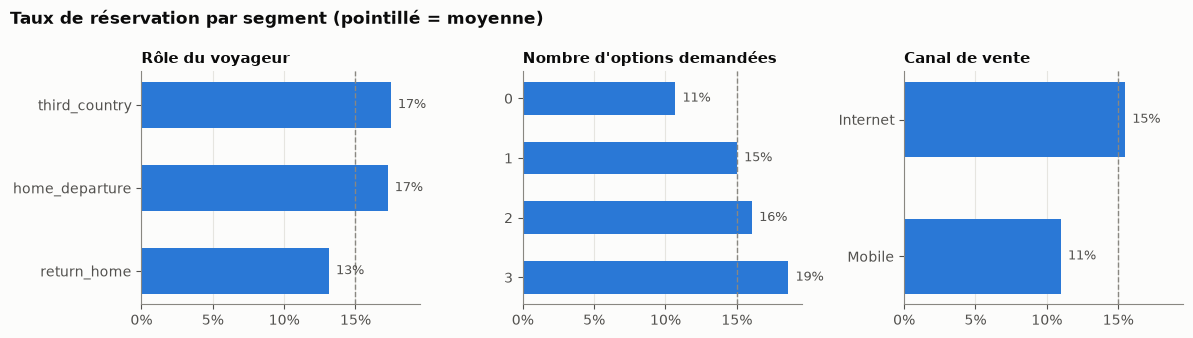

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
panels = [("origin_role", "Rôle du voyageur"), ("n_extras", "Nombre d'options demandées"), ("sales_channel", "Canal de vente")]
for ax, (col, title) in zip(axes, panels):
    c = conversion(df, col).sort_index(ascending=False) if col == "n_extras" else conversion(df, col).iloc[::-1]
    labels = c.index.astype(str)
    ax.barh(labels, c.rate, color=BLUE, height=0.55)
    ax.axvline(BASE_RATE, color=MUTED, ls="--", lw=1)
    for i, (r, n) in enumerate(zip(c.rate, c.n)):
        ax.text(r + 0.005, i, f"{r:.0%}", va="center", fontsize=9, color=INK2)
    ax.set_title(title, fontsize=11); ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.suptitle("Taux de réservation par segment (pointillé = moyenne)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "conversion_by_segment.png", dpi=200); plt.show()

## 3. Préparation pour la modélisation

In [10]:
TARGET = "booking_complete"
HIGH_CARD = ["route", "booking_origin"]                       # encodage par la cible (dans le pipeline)
LOW_CARD_BASE = ["sales_channel", "trip_type"]
NUM_BASE = ["num_passengers", "purchase_lead", "length_of_stay", "flight_hour", "flight_day",
            "wants_extra_baggage", "wants_preferred_seat", "wants_in_flight_meals", "flight_duration"]
LOW_CARD_ENG = LOW_CARD_BASE + ["origin_role", "dest_region"]
NUM_ENG = NUM_BASE + ["n_extras", "stay_weekend", "last_minute", "red_eye"]
FEATURES = HIGH_CARD + LOW_CARD_ENG + NUM_ENG
CAT_COLS = HIGH_CARD + LOW_CARD_ENG

X, y = df[FEATURES], df[TARGET]

def preprocessor(low_card, num, scale=False, onehot=False):
    cat = (OneHotEncoder(handle_unknown="ignore", sparse_output=False) if onehot
           else OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    return ColumnTransformer([
        ("te", TargetEncoder(target_type="binary", cv=StratifiedKFold(5, shuffle=True, random_state=SEED)), HIGH_CARD),
        ("cat", cat, low_card),
        ("num", StandardScaler() if scale else "passthrough", num),
    ], verbose_feature_names_out=False)

**Pourquoi encoder par la cible à l'intérieur du pipeline ?**
Encoder `route` par son taux de réservation calculé sur toutes les lignes ferait « voir » la cible au modèle. Dans un premier test rapide, cela gonflait l'AUC à 0,81. `TargetEncoder` fait du *cross-fitting* sur les seules données d'apprentissage, et les données d'évaluation ne sont jamais vues. CatBoost applique le même principe en interne (*ordered target statistics*).

### Découpage 70 / 15 / 15 (stratifié)
| Jeu | Rôle |
|---|---|
| **Train (70 %)** | apprentissage des modèles |
| **Validation (15 %)** | réglage des hyperparamètres, arrêt anticipé, choix du modèle et du seuil de décision |
| **Test (15 %)** | **une seule** évaluation finale, jamais utilisé avant |

In [11]:
X_trval, X_test, y_trval, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trval, y_trval, test_size=0.15 / 0.85, stratify=y_trval,
                                                  random_state=SEED)
pd.DataFrame({"rows": [len(X_train), len(X_val), len(X_test)],
              "share": [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
              "booking rate": [y_train.mean(), y_val.mean(), y_test.mean()]},
             index=["train", "validation", "test"])

,rows,share,booking rate
train,34495,0.700,0.150
validation,7393,0.150,0.150
test,7393,0.150,0.150


## 4. Premier banc d'essai : validation croisée des modèles par défaut

Avant de régler quoi que ce soit, on compare des modèles avec leurs réglages par défaut. On utilise une validation croisée en 5 plis sur **train + validation (85 %)** : le test reste intact. On mesure aussi l'apport des variables créées (RF « raw » contre « engineered »).

In [12]:
def rf_default():
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=3, max_features="sqrt",
                                  class_weight="balanced_subsample", n_jobs=-1, random_state=SEED)

RAW = HIGH_CARD + LOW_CARD_BASE + NUM_BASE
models = {
    "Logistic regression": (Pipeline([("prep", preprocessor(LOW_CARD_ENG, NUM_ENG, scale=True, onehot=True)),
                                      ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]), FEATURES),
    "Random Forest – raw features": (Pipeline([("prep", preprocessor(LOW_CARD_BASE, NUM_BASE)), ("clf", rf_default())]), RAW),
    "Random Forest – engineered": (Pipeline([("prep", preprocessor(LOW_CARD_ENG, NUM_ENG)), ("clf", rf_default())]), FEATURES),
    "XGBoost – engineered": (Pipeline([("prep", preprocessor(LOW_CARD_ENG, NUM_ENG)),
                                       ("clf", XGBClassifier(n_estimators=300, learning_rate=0.05, tree_method="hist",
                                                             n_jobs=-1, random_state=SEED))]), FEATURES),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
for name, (model, cols) in models.items():
    res = cross_validate(model, X_trval[cols], y_trval, cv=cv, scoring={"ROC-AUC": "roc_auc", "PR-AUC": "average_precision"})
    rows.append({"model": name, "ROC-AUC": res["test_ROC-AUC"].mean(), "ROC-AUC_std": res["test_ROC-AUC"].std(),
                 "PR-AUC": res["test_PR-AUC"].mean(), "PR-AUC_std": res["test_PR-AUC"].std()})
cv_results = pd.DataFrame(rows).set_index("model")
cv_results

,ROC-AUC,ROC-AUC_std,PR-AUC,PR-AUC_std
model,,,,
Logistic regression,0.779,0.006,0.354,0.009
Random Forest – raw features,0.790,0.004,0.384,0.005
Random Forest – engineered,0.791,0.004,0.384,0.004
XGBoost – engineered,0.790,0.005,0.378,0.007


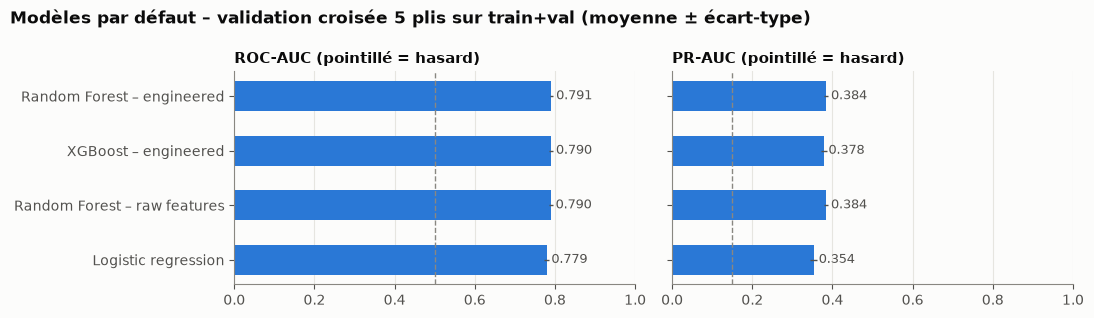

In [13]:
order = cv_results.sort_values("ROC-AUC").index
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, metric, ref in [(axes[0], "ROC-AUC", 0.5), (axes[1], "PR-AUC", BASE_RATE)]:
    vals, err = cv_results.loc[order, metric], cv_results.loc[order, f"{metric}_std"]
    ax.barh(order, vals, xerr=err, color=BLUE, height=0.55, error_kw={"ecolor": INK2, "lw": 1})
    ax.axvline(ref, color=MUTED, ls="--", lw=1)
    for i, v in enumerate(vals):
        ax.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=9, color=INK2)
    ax.set_title(f"{metric} (pointillé = hasard)", fontsize=11); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 1)
fig.suptitle("Modèles par défaut – validation croisée 5 plis sur train+val (moyenne ± écart-type)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "model_comparison_cv.png", dpi=200); plt.show()

## 5. Réglage des hyperparamètres (Optuna) – Random Forest, XGBoost, CatBoost

- **Métrique optimisée : la PR-AUC sur la validation.** Avec 15 % de positifs, elle mesure directement la qualité du classement des vrais réservants. La ROC-AUC est flattée par la masse de négatifs faciles.
- **Recherche bayésienne (TPE)** avec Optuna. Le **premier essai de chaque étude reprend les réglages par défaut**, ce qui permet de mesurer le gain réel du réglage.
- **XGBoost et CatBoost** utilisent l'arrêt anticipé (*early stopping*) sur la validation. Le nombre d'arbres n'est donc pas un paramètre à régler.
- **CatBoost** reçoit `route`, `booking_origin`, etc. en catégories brutes et les encode lui-même.

In [14]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def fit_rf(p):
    m = Pipeline([("prep", preprocessor(LOW_CARD_ENG, NUM_ENG)),
                  ("clf", RandomForestClassifier(**p, class_weight="balanced_subsample", n_jobs=-1, random_state=SEED))])
    return m.fit(X_train, y_train)

def fit_xgb(p):
    prep = preprocessor(LOW_CARD_ENG, NUM_ENG)
    Xt_train = prep.fit_transform(X_train, y_train)          # cross-fitted encoding on train (no leakage)
    clf = XGBClassifier(**p, n_estimators=3000, early_stopping_rounds=100, eval_metric="aucpr",
                        tree_method="hist", n_jobs=-1, random_state=SEED)
    clf.fit(Xt_train, y_train, eval_set=[(prep.transform(X_val), y_val)], verbose=False)
    return Pipeline([("prep", prep), ("clf", clf)])

def fit_cat(p):
    clf = CatBoostClassifier(**p, iterations=3000, od_type="Iter", od_wait=150, eval_metric="Logloss",
                             cat_features=CAT_COLS, random_seed=SEED, verbose=False, thread_count=-1)
    return clf.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

SEARCH = {
    "Random Forest": dict(
        fit=fit_rf, n_trials=20,
        default={"n_estimators": 300, "max_depth": None, "min_samples_leaf": 3, "max_features": "sqrt"},
        space=lambda t: {"n_estimators": t.suggest_int("n_estimators", 200, 600, step=100),
                         "max_depth": t.suggest_categorical("max_depth", [None, 10, 15, 20, 30]),
                         "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 30, log=True),
                         "max_features": t.suggest_categorical("max_features", ["sqrt", 0.3, 0.5, 0.7])}),
    "XGBoost": dict(
        fit=fit_xgb, n_trials=30,
        default={"learning_rate": 0.3, "max_depth": 6, "min_child_weight": 1, "subsample": 1.0,
                 "colsample_bytree": 1.0, "reg_lambda": 1.0},
        space=lambda t: {"learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                         "max_depth": t.suggest_int("max_depth", 3, 10),
                         "min_child_weight": t.suggest_int("min_child_weight", 1, 30, log=True),
                         "subsample": t.suggest_float("subsample", 0.5, 1.0),
                         "colsample_bytree": t.suggest_float("colsample_bytree", 0.4, 1.0),
                         "reg_lambda": t.suggest_float("reg_lambda", 0.1, 30, log=True)}),
    "CatBoost": dict(
        fit=fit_cat, n_trials=15,
        default={"learning_rate": 0.1, "depth": 6, "l2_leaf_reg": 3.0, "random_strength": 1.0},
        space=lambda t: {"learning_rate": t.suggest_float("learning_rate", 0.03, 0.2, log=True),
                         "depth": t.suggest_int("depth", 4, 9),
                         "l2_leaf_reg": t.suggest_float("l2_leaf_reg", 1, 30, log=True),
                         "random_strength": t.suggest_float("random_strength", 0.1, 3, log=True)}),
}

def val_pr_auc(model):
    return average_precision_score(y_val, model.predict_proba(X_val)[:, 1])

studies = {}
for name, cfg in SEARCH.items():
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.enqueue_trial(cfg["default"])
    study.optimize(lambda t: val_pr_auc(cfg["fit"](cfg["space"](t))), n_trials=cfg["n_trials"])
    studies[name] = study
    print(f"{name:14s} default PR-AUC = {study.trials[0].value:.4f}  ->  tuned = {study.best_value:.4f}  "
          f"({cfg['n_trials']} trials)")

Random Forest  default PR-AUC = 0.3882  ->  tuned = 0.3923  (20 trials)


XGBoost        default PR-AUC = 0.3914  ->  tuned = 0.3988  (30 trials)


CatBoost       default PR-AUC = 0.3944  ->  tuned = 0.4005  (15 trials)


In [15]:
tuned, rows = {}, []
for name, cfg in SEARCH.items():
    params = {**cfg["default"], **studies[name].best_params}
    m = cfg["fit"](params)
    tuned[name] = m
    p_val = m.predict_proba(X_val)[:, 1]
    rows.append({"model": name, "val PR-AUC (default)": studies[name].trials[0].value,
                 "val PR-AUC (tuned)": average_precision_score(y_val, p_val),
                 "val ROC-AUC (tuned)": roc_auc_score(y_val, p_val), "best params": studies[name].best_params})
tuning = pd.DataFrame(rows).set_index("model")
FINAL_NAME = tuning["val PR-AUC (tuned)"].idxmax()
final_model = tuned[FINAL_NAME]
print("Modèle retenu (meilleure PR-AUC de validation) :", FINAL_NAME)
pd.set_option("display.max_colwidth", 200)
tuning

Modèle retenu (meilleure PR-AUC de validation) : CatBoost


,val PR-AUC (default),val PR-AUC (tuned),val ROC-AUC (tuned),best params
model,,,,
Random Forest,0.388,0.392,0.792,"{'n_estimators': 600, 'max_depth': 20, 'min_samples_leaf': 7, 'max_features': 0.3}"
XGBoost,0.391,0.399,0.792,"{'learning_rate': 0.07610027578788958, 'max_depth': 6, 'min_child_weight': 12, 'subsample': 0.9486190424387335, 'colsample_bytree': 0.9601643429317813, 'reg_lambda': 5.02154782534732}"
CatBoost,0.394,0.401,0.796,"{'learning_rate': 0.03288449574330335, 'depth': 9, 'l2_leaf_reg': 29.516670487927733, 'random_strength': 0.938066787090875}"


**Lecture du réglage**
- Le réglage apporte un **gain réel mais modeste** : +0,004 à +0,008 de PR-AUC sur la validation.
- **CatBoost l'emporte de peu.** Son encodage natif des catégories (route, pays) est un avantage sur ce jeu de données.
- Les hyperparamètres retenus vont tous dans le sens de **plus de régularisation** : `min_samples_leaf` élevé pour le RF, `min_child_weight` et `reg_lambda` pour XGBoost, `l2_leaf_reg` proche de 30 pour CatBoost. Le signal est bruité, et les modèles gagnent à ne pas sur-apprendre.

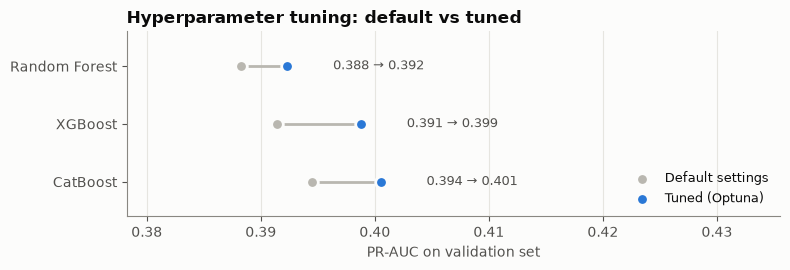

In [16]:
fig, ax = plt.subplots(figsize=(8, 2.8))
names = list(tuning.index)
for i, n in enumerate(names):
    d, t = tuning.loc[n, "val PR-AUC (default)"], tuning.loc[n, "val PR-AUC (tuned)"]
    ax.plot([d, t], [i, i], color=GREY, lw=2, zorder=1)
    ax.scatter(d, i, s=70, color=GREY, edgecolor=SURFACE, linewidth=2, zorder=2, label="Default settings" if i == 0 else None)
    ax.scatter(t, i, s=70, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3, label="Tuned (Optuna)" if i == 0 else None)
    ax.text(max(d, t) + 0.004, i, f"{d:.3f} → {t:.3f}", va="center", fontsize=9, color=INK2)
ax.set_yticks(range(len(names)), names); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
lo = tuning[["val PR-AUC (default)", "val PR-AUC (tuned)"]].min().min()
hi = tuning[["val PR-AUC (default)", "val PR-AUC (tuned)"]].max().max()
ax.set_xlim(lo - 0.01, hi + 0.035); ax.set_ylim(len(names) - 0.4, -0.6)
ax.set_xlabel("PR-AUC on validation set")
ax.set_title("Hyperparameter tuning: default vs tuned")
ax.legend(frameon=False, loc="lower right", fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "tuning_gain.png", dpi=200); plt.show()

## 6. Évaluation finale sur le jeu de test (15 %, jamais vu)

- **Le seuil de décision est choisi sur la validation** (celui qui maximise le F1), puis appliqué tel quel au test. Les métriques de test sont donc sans biais d'optimisation.
- Les scores des trois modèles réglés sont affichés par transparence. **Le choix du modèle a été fait sur la validation, pas sur le test.**

In [17]:
prec, rec, thr = precision_recall_curve(y_val, final_model.predict_proba(X_val)[:, 1])
f1 = 2 * prec * rec / (prec + rec + 1e-12)
THRESHOLD = thr[np.nanargmax(f1[:-1])]

def test_metrics(model, threshold):
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= threshold).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    return {"ROC-AUC": roc_auc_score(y_test, p), "PR-AUC": average_precision_score(y_test, p),
            "Precision": tp / max(pred.sum(), 1), "Recall": tp / y_test.sum(),
            "F1": 2 * tp / (pred.sum() + y_test.sum())}

test_table = {}
for name, m in tuned.items():
    pv, rv, tv = precision_recall_curve(y_val, m.predict_proba(X_val)[:, 1])
    th = tv[np.nanargmax((2 * pv * rv / (pv + rv + 1e-12))[:-1])]
    test_table[name] = test_metrics(m, th)
test_table = pd.DataFrame(test_table).T
test_table

,ROC-AUC,PR-AUC,Precision,Recall,F1
Random Forest,0.793,0.370,0.367,0.500,0.423
XGBoost,0.793,0.370,0.350,0.558,0.430
CatBoost,0.795,0.372,0.356,0.552,0.433


In [18]:
p_test = final_model.predict_proba(X_test)[:, 1]
pred_test = (p_test >= THRESHOLD).astype(int)
TEST = test_table.loc[FINAL_NAME]
print(f"{FINAL_NAME} – seuil (choisi sur la validation) = {THRESHOLD:.2f}")
print(f"Test : ROC-AUC = {TEST['ROC-AUC']:.3f} | PR-AUC = {TEST['PR-AUC']:.3f} (hasard = {y_test.mean():.3f})")
print(classification_report(y_test, pred_test, digits=3))
pd.DataFrame(confusion_matrix(y_test, pred_test), index=["réel : non", "réel : oui"],
             columns=["prédit : non", "prédit : oui"])

CatBoost – seuil (choisi sur la validation) = 0.27
Test : ROC-AUC = 0.795 | PR-AUC = 0.372 (hasard = 0.150)
              precision    recall  f1-score   support

           0      0.912     0.824     0.866      6284
           1      0.356     0.552     0.433      1109

    accuracy                          0.783      7393
   macro avg      0.634     0.688     0.650      7393
weighted avg      0.829     0.783     0.801      7393



,prédit : non,prédit : oui
réel : non,5179,1105
réel : oui,497,612


### Courbe de gain : la lecture business
On trie les clients du test par probabilité prédite. Si on n'agit que sur les X % les mieux notés (relance, offre ciblée), quelle part des réservations capte-t-on ?

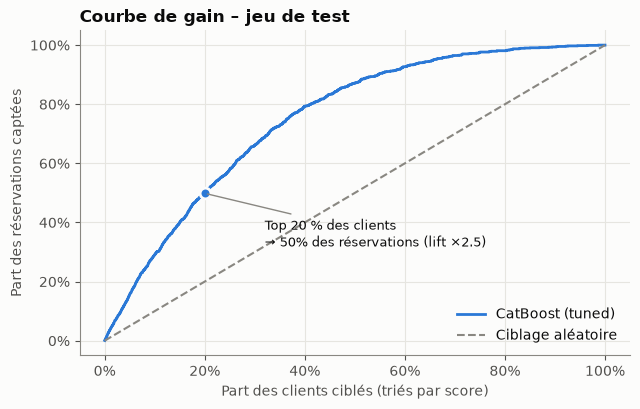

In [19]:
order_idx = np.argsort(-p_test)
captured = np.cumsum(y_test.to_numpy()[order_idx]) / y_test.sum()
share = np.arange(1, len(y_test) + 1) / len(y_test)
CAPTURE_20 = captured[int(0.2 * len(y_test)) - 1]
LIFT_20 = CAPTURE_20 / 0.2

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(share, captured, color=BLUE, lw=2, label=f"{FINAL_NAME} (tuned)")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1.5, ls="--", label="Ciblage aléatoire")
ax.scatter([0.2], [CAPTURE_20], color=BLUE, s=60, zorder=3, edgecolor=SURFACE, linewidth=2)
ax.annotate(f"Top 20 % des clients\n→ {CAPTURE_20:.0%} des réservations (lift ×{LIFT_20:.1f})",
            xy=(0.2, CAPTURE_20), xytext=(0.32, CAPTURE_20 - 0.18), fontsize=9.5, color=INK,
            arrowprops={"arrowstyle": "-", "color": MUTED})
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}"); ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_xlabel("Part des clients ciblés (triés par score)"); ax.set_ylabel("Part des réservations captées")
ax.set_title("Courbe de gain – jeu de test"); ax.legend(frameon=False, loc="lower right")
fig.tight_layout(); fig.savefig(FIG_DIR / "gain_curve.png", dpi=200); plt.show()

## 7. Interprétation : quelles variables comptent ?

1. **Importance par permutation** sur le jeu de test : de combien l'AUC chute-t-elle quand on mélange une variable ? Elle est calculée sur les colonnes d'origine, quel que soit le modèle. Contrairement à l'importance native par impureté, elle ne favorise pas les variables à forte cardinalité.
2. **SHAP** : dans quel **sens** chaque variable pousse la probabilité de réserver.

In [20]:
auc_scorer = lambda est, X_, y_: roc_auc_score(y_, est.predict_proba(X_)[:, 1])
perm = permutation_importance(final_model, X_test, y_test, scoring=auc_scorer, n_repeats=10,
                              random_state=SEED, n_jobs=1)
imp = pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std},
                   index=FEATURES).sort_values("importance", ascending=False)
imp

,importance,std
booking_origin,0.118,0.005
route,0.070,0.003
length_of_stay,0.010,0.001
n_extras,0.009,0.002
sales_channel,0.008,0.001
purchase_lead,0.005,0.001
origin_role,0.003,0.001
wants_extra_baggage,0.002,0.000
flight_duration,0.002,0.000
dest_region,0.001,0.001


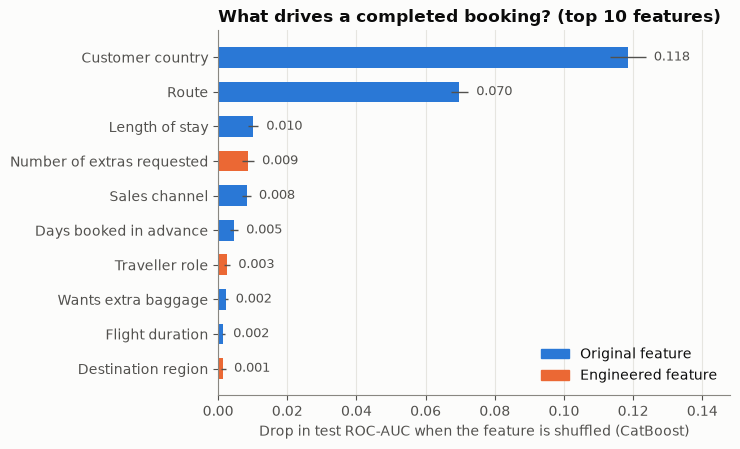

In [21]:
LABELS = {
    "route": "Route", "booking_origin": "Customer country", "purchase_lead": "Days booked in advance",
    "length_of_stay": "Length of stay", "flight_hour": "Departure hour", "flight_day": "Departure day",
    "flight_duration": "Flight duration", "origin_role": "Traveller role",
    "wants_extra_baggage": "Wants extra baggage", "wants_preferred_seat": "Wants preferred seat",
    "wants_in_flight_meals": "Wants in-flight meals", "n_extras": "Number of extras requested",
    "num_passengers": "Number of passengers", "sales_channel": "Sales channel", "trip_type": "Trip type",
    "dest_region": "Destination region", "stay_weekend": "Stay includes weekend",
    "last_minute": "Last-minute booking", "red_eye": "Red-eye departure",
}
ENGINEERED = {"origin_role", "n_extras", "dest_region", "stay_weekend", "last_minute", "red_eye"}
ORANGE = "#eb6834"

top = imp.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
colors = [ORANGE if f in ENGINEERED else BLUE for f in top.index]
ax.barh([LABELS[f] for f in top.index], top.importance, xerr=top["std"], color=colors, height=0.6,
        error_kw={"ecolor": INK2, "lw": 1})
for i, (v, sd) in enumerate(zip(top.importance, top["std"])):
    ax.text(v + sd + top.importance.max() * 0.02, i, f"{v:.3f}", va="center", fontsize=9, color=INK2)
ax.set_xlabel(f"Drop in test ROC-AUC when the feature is shuffled ({FINAL_NAME})")
ax.set_title("What drives a completed booking? (top 10 features)")
ax.grid(axis="y", visible=False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="Original feature"), Patch(color=ORANGE, label="Engineered feature")],
          frameon=False, loc="lower right")
ax.set_xlim(0, top.importance.max() * 1.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "feature_importance.png", dpi=220); plt.show()

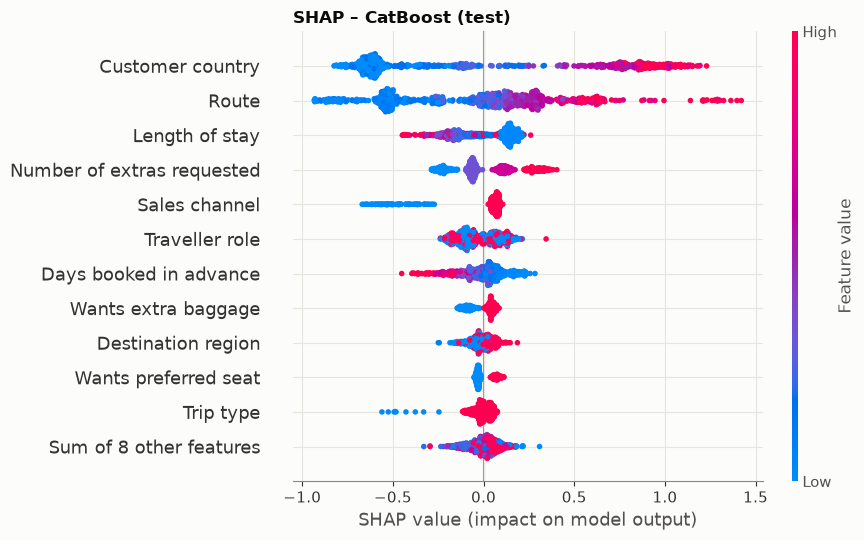

In [22]:
X_shap = X_test.sample(800, random_state=SEED)
if isinstance(final_model, CatBoostClassifier):
    raw = final_model.get_feature_importance(Pool(X_shap, cat_features=CAT_COLS), type="ShapValues")
    # Colour categorical features by their training booking rate (high = high-converting category)
    data = X_shap.copy()
    for c in CAT_COLS:
        data[c] = data[c].map(y_train.groupby(X_train[c]).mean()).astype(float)
    sv = shap.Explanation(values=raw[:, :-1], base_values=raw[:, -1], data=data.to_numpy(dtype=float),
                          feature_names=[LABELS[c] for c in FEATURES])
else:
    prep, clf = final_model.named_steps["prep"], final_model.named_steps["clf"]
    Xt = pd.DataFrame(prep.transform(X_shap), columns=prep.get_feature_names_out()).rename(columns=LABELS)
    sv = shap.TreeExplainer(clf)(Xt)
    if sv.values.ndim == 3:
        sv = sv[:, :, 1]
shap.plots.beeswarm(sv, max_display=12, show=False)
plt.title(f"SHAP – {FINAL_NAME} (test)", loc="left", fontweight="bold")
plt.gcf().set_size_inches(9, 5.5); plt.tight_layout()
plt.savefig(FIG_DIR / "shap_beeswarm.png", dpi=200); plt.show()

**Lecture du graphique SHAP** : chaque point est un client. Rouge = valeur élevée de la variable, bleu = valeur faible. Pour le pays et la route, « élevée » signifie un pays ou une route qui convertit beaucoup. À droite, le client est poussé vers la réservation ; à gauche, il en est éloigné.

In [23]:
# Chiffres clés réutilisés dans la synthèse et la diapositive
role = conversion(df, "origin_role")["rate"]
extras = conversion(df, "n_extras")["rate"]
mobile = conversion(df, "sales_channel")["rate"]
summary = {
    "final": FINAL_NAME, "test_auc": TEST["ROC-AUC"], "test_ap": TEST["PR-AUC"], "test_f1": TEST["F1"],
    "test_rate": y_test.mean(), "capture20": CAPTURE_20, "lift20": LIFT_20,
    "auc_range": (test_table["ROC-AUC"].min(), test_table["ROC-AUC"].max()),
    "rf_auc_raw": cv_results.loc["Random Forest – raw features", "ROC-AUC"],
    "rf_auc_eng": cv_results.loc["Random Forest – engineered", "ROC-AUC"],
    "role": role.to_dict(), "extras0": extras.get(0), "extras3": extras.get(3),
    "internet": mobile.get("Internet"), "mobile": mobile.get("Mobile"),
}
summary

{'final': 'CatBoost',
 'test_auc': np.float64(0.7946769932253841),
 'test_ap': np.float64(0.37170428548011375),
 'test_f1': np.float64(0.43312101910828027),
 'test_rate': np.float64(0.15000676315433517),
 'capture20': np.float64(0.49864743011722273),
 'lift20': np.float64(2.4932371505861135),
 'auc_range': (np.float64(0.7926475644271538), np.float64(0.7946769932253841)),
 'rf_auc_raw': np.float64(0.7895582997176267),
 'rf_auc_eng': np.float64(0.7908833008674988),
 'role': {'third_country': 0.17471344216741924,
  'home_departure': 0.1725121925910553,
  'return_home': 0.1313403125921557},
 'extras0': np.float64(0.10692188708430007),
 'extras3': np.float64(0.1861140137002206),
 'internet': np.float64(0.15488307489127218),
 'mobile': np.float64(0.10980611483967188)}

## 8. Diapositive de synthèse

In [24]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_SHAPE

NAVY, ACCENT, GREY_TXT, LIGHT = RGBColor(0x0B, 0x1F, 0x3A), RGBColor(0x2A, 0x78, 0xD6), RGBColor(0x52, 0x51, 0x4E), RGBColor(0xF2, 0xF4, 0xF7)
s = summary

prs = Presentation()
prs.slide_width, prs.slide_height = Inches(13.333), Inches(7.5)
slide = prs.slides.add_slide(prs.slide_layouts[6])

def box(x, y, w, h, fill=None):
    shp = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(x), Inches(y), Inches(w), Inches(h))
    shp.line.fill.background()
    if fill is None: shp.fill.background()
    else: shp.fill.solid(); shp.fill.fore_color.rgb = fill
    return shp

def text(x, y, w, h, runs, size=12, color=GREY_TXT, bold=False, space=4):
    tb = slide.shapes.add_textbox(Inches(x), Inches(y), Inches(w), Inches(h)).text_frame
    tb.word_wrap = True
    for i, r in enumerate(runs if isinstance(runs, list) else [runs]):
        p = tb.paragraphs[0] if i == 0 else tb.add_paragraph()
        p.space_after = Pt(space)
        parts = r if isinstance(r, list) else [(r, bold)]
        for t, b in parts:
            run = p.add_run(); run.text = t
            run.font.size, run.font.bold, run.font.color.rgb, run.font.name = Pt(size), b, color, "Calibri"
    return tb

# Header band
box(0, 0, 13.333, 1.15, NAVY)
text(0.5, 0.18, 12.3, 0.6, "Predicting customer bookings: who completes a booking, and why?", 26, RGBColor(255, 255, 255), True)
text(0.5, 0.68, 12.3, 0.4, f"{len(df):,} booking requests · 70/15/15 split · Random Forest, XGBoost & CatBoost tuned on validation "
     f"· best: {s['final']} · scores on unseen test set", 12.5, RGBColor(0xC9, 0xD6, 0xE8))

# KPI tiles
kpis = [(f"{s['test_auc']:.2f}", "ROC-AUC on unseen test set"),
        (f"{s['test_ap']:.2f}", f"PR-AUC vs {s['test_rate']:.2f} at random"),
        (f"{s['capture20']:.0%}", "of bookings captured by\nthe top 20% scored customers")]
for i, (big, small) in enumerate(kpis):
    x = 0.5 + i * 2.35
    box(x, 1.45, 2.15, 1.35, LIGHT)
    text(x + 0.15, 1.5, 1.9, 0.7, big, 30, ACCENT, True)
    text(x + 0.15, 2.15, 1.95, 0.65, small.split("\n"), 10.5, GREY_TXT, space=0)

# Chart
slide.shapes.add_picture(str(FIG_DIR / "feature_importance.png"), Inches(0.45), Inches(3.0), width=Inches(7.0))

# Insights
text(7.9, 1.4, 5.0, 0.4, "Key findings", 16, NAVY, True)
role_d = s["role"]
origin_rates = conversion(df, "booking_origin")["rate"]
lo, hi = s["auc_range"]
insights = [
    [("Who books, and where to, dominates. ", True),
     (f"Customer country and route are by far the strongest drivers. Malaysia converts at "
      f"{origin_rates['Malaysia']:.0%} vs {origin_rates['Australia']:.0%} for Australia, our largest market.", False)],
    [("Short, near-term trips convert better. ", True),
     (f"Longer stays and bookings made far in advance lower the probability; mobile converts at "
      f"{s['mobile']:.0%} vs {s['internet']:.0%} on web.", False)],
    [("Engagement and intent signal buying. ", True),
     (f"All 3 extras requested: {s['extras3']:.0%} conversion vs {s['extras0']:.0%} with none. "
      f"Return-leg bookings convert less ({role_d['return_home']:.0%} vs {role_d['home_departure']:.0%} outbound).", False)],
    [("Data, not algorithm, is the limit. ", True),
     (f"Tuned Random Forest, XGBoost and CatBoost all land at {lo:.3f}–{hi:.3f} test ROC-AUC; "
      f"richer session data (searches, prices seen) is the next lever.", False)],
]
text(7.9, 1.85, 5.0, 3.9, insights, 11.5, GREY_TXT, space=8)

# Recommendation band
box(7.9, 5.0, 4.95, 1.35, LIGHT)
box(7.9, 5.0, 0.08, 1.35, ACCENT)
text(8.1, 5.05, 4.7, 1.3, [[("Recommendation: ", True),
     (f"use the score to prioritise follow-ups on the top 20% of requests (~{s['capture20']:.0%} of all bookings), "
      "push bundled extras during booking, and investigate the mobile funnel and the Australian market "
      "(high volume, low conversion).", False)]], 11.5, NAVY)

prs.save("booking_prediction_summary.pptx")
print("Saved -> booking_prediction_summary.pptx")

Saved -> booking_prediction_summary.pptx


## 9. Conclusion

- **Protocole** : découpage 70/15/15 stratifié. Random Forest, XGBoost et CatBoost sont réglés avec Optuna (65 essais au total) sur la PR-AUC de validation. Le seuil de décision est choisi sur la validation, et l'évaluation finale est faite **une seule fois** sur le test.
- **Modèle retenu : CatBoost réglé.** Sur le test, il obtient une **ROC-AUC de 0,795**, une **PR-AUC de 0,372** (contre 0,15 au hasard) et un F1 de 0,43 (précision 0,36, rappel 0,55). En ciblant les **20 % de demandes les mieux notées, on capte environ 50 % des réservations** (lift ×2,5).
- **Les trois modèles réglés finissent à moins de 0,003 d'AUC les uns des autres** (0,793–0,795). Le réglage aide un peu, mais **la limite vient des données, pas de l'algorithme**.
- **Facteurs principaux** : le pays du client et la route dominent. Viennent ensuite la durée du séjour, le nombre d'options demandées, le canal de vente et le délai de réservation.
- **Sens des effets (SHAP)** : un séjour long, une réservation très en avance et le canal mobile réduisent la probabilité de réserver. Demander des options l'augmente.
- **Hypothèse testée honnêtement** : le « rôle du voyageur » montre que les trajets retour convertissent moins (13 % contre 17 %). Mais une fois le pays et la route connus, les variables créées n'apportent presque rien. Le signal est déjà contenu dans le couple pays × route.
- **Pistes** : ajouter des données de session (nombre de recherches, prix affiché, temps passé), faire une validation temporelle si une date de réservation devient disponible, et calibrer les probabilités pour un usage opérationnel.